In [ ]:
!pip install pettingzoo[mpe] stable-baselines3 torch wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 21.6 MB/s eta 0:00:00


In [ ]:
!pip install supersuit -q
!pip install supersuit stable-baselines3 pettingzoo[mpe] -q
!pip install supersuit pettingzoo[mpe] gymnasium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 13.8 MB/s eta 0:00:00


/tmp/ipython-input-1376/4199671495.py:4: DeprecationWarning: The environment `pettingzoo.mpe` has been moved to `mpe2` and will be removed in a future release.Please update your imports.
  from pettingzoo.mpe import simple_adversary_v3



>>> 1_MAPPO_Baseline | Mode: mappo <<<


1_MAPPO_Baseline: 100%|██████████| 1000/1000 [07:23<00:00,  2.26it/s]



>>> 2_ALP_GMM_Curriculum | Mode: mappo <<<


2_ALP_GMM_Curriculum: 100%|██████████| 1000/1000 [07:32<00:00,  2.21it/s]


...


>>> 4_MAMBA_SOTA | Mode: mamba <<<


4_MAMBA_SOTA: 100%|██████████| 1000/1000 [18:25<00:00,  1.11s/it]



>>> 5_Full_CGAWM_Hybrid | Mode: hybrid <<<


5_Full_CGAWM_Hybrid: 100%|██████████| 1000/1000 [18:41<00:00,  1.12s/it]



=== FINAL SOTA COMPARISON ===
            Baseline  Best Reward
    1_MAPPO_Baseline   102.433319
2_ALP_GMM_Curriculum    88.270134
    3_DreamerV3_SOTA    62.058670
        4_MAMBA_SOTA   118.397186
 5_Full_CGAWM_Hybrid   187.618149


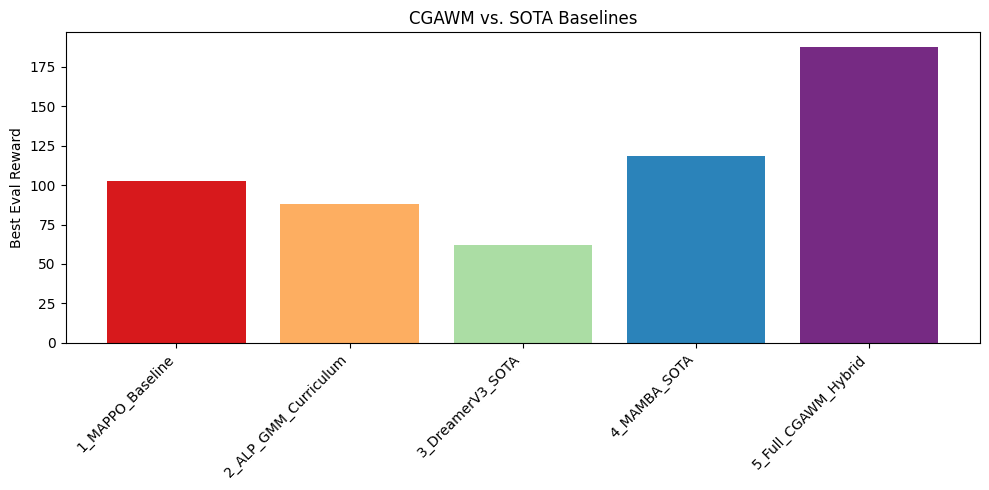

In [ ]:
import os, torch, torch.nn as nn, torch.optim as optim
import numpy as np, random, collections, copy, datetime, json
import matplotlib.pyplot as plt
from pettingzoo.mpe import simple_adversary_v3
import gymnasium as gym
from tqdm import tqdm
import pandas as pd

# ---------- 0. SEEDING ----------
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------- 1. LOCKED CONFIG ----------
THESIS_LOCK = {
    'env_id': 'simple_adversary_v3',
    'max_cycles': 50,
    'curriculum_stages': [1, 2, 3],
    'curriculum_threshold': -5.0,
    'curriculum_window': 50,
    'use_model': True,
    'num_ensemble_models': 5,
    'dynamics_lr': 1e-4,
    'dynamics_weight_decay': 1e-4,
    'imagination_horizon': 1,
    'imagination_batch_size': 64,
    'model_data_ratio': 0.80,
    'imagination_frequency': 1,
    'eps_start': 1.0,
    'eps_decay': 0.999,
    'eps_min': 0.3,
    'bonus_scale': 0.05,
    'bonus_clip': (-1.0, 1.0),
    'batch_size': 128,
    'real_cap': 20000,
    'model_cap': 20000,
    'gamma': 0.99,
    'tau': 0.005,
    'ent_coef': 0.5,
    'p_lr': 1e-4,
    'c_lr': 1e-4,
    'd_lr': 1e-4,
    'grad_clip': 0.5,
    'target_update_freq': 1000,
    'max_episodes': 1000,
    'eval_interval': 50,
}

# ---------- 2. ENV & CURRICULUM ----------
class CurriculumManager:
    def __init__(self, stages, threshold=-5.0, window=50):
        self.stages = stages; self.th = threshold; self.win = window
        self.buf = collections.deque(maxlen=window); self.idx = 0
    def stage(self): return self.stages[self.idx]
    def update(self, r):
        self.buf.append(r)
        if len(self.buf) == self.win and np.mean(self.buf) >= self.th and self.idx < len(self.stages)-1:
            self.idx += 1; self.buf.clear(); return True
        return False

def make_training_env(num_adv=1, max_obs_dim=None):
    base = simple_adversary_v3.parallel_env(N=num_adv, max_cycles=50, continuous_actions=False)
    class Flat(gym.Env):
        def __init__(self, pz, max_dim):
            self.pz = pz; self.ags = pz.possible_agents
            self.max_dim = max_dim
            n = self.pz.action_space(self.ags[0]).n
            self.action_space = gym.spaces.MultiDiscrete([n] * len(self.ags))
            obs_sz = sum([pz.observation_space(a).shape[0] for a in self.ags])
            self.observation_space = gym.spaces.Box(-np.inf, np.inf, (max_dim if max_dim else obs_sz,), np.float32)
            self.last_d = 0
        def reset(self, seed=None, options=None):
            obs, info = self.pz.reset(seed=seed); self.last_d = self._d(obs); return self._flat(obs), info
        def step(self, acts):
            acts_dict = {a: int(acts[i]) for i, a in enumerate(self.ags)}
            obs, rew, term, trunc, info = self.pz.step(acts_dict)
            done = all(term.values()) or all(trunc.values())
            d = self._d(obs); dr = d - self.last_d; self.last_d = d
            r = rew.get('agent_0', 0.0) + (dr * 1.0 + 0.05)
            return self._flat(obs), r, done, False, {}
        def _d(self, obs):
            lp = obs['agent_0'][:2]
            ap = [obs[a][:2] for a in obs if 'adversary' in a]
            return 0 if not ap else np.min(np.linalg.norm(np.array(ap) - lp, axis=1))
        def _flat(self, obs):
            arr = np.concatenate([obs[a] for a in self.ags if a in obs])
            if self.max_dim and len(arr) < self.max_dim:
                return np.pad(arr, (0, self.max_dim - len(arr)), 'constant')
            return arr
        def close(self): self.pz.close()
    return Flat(base, max_obs_dim)

# ---------- 3. NETWORKS & BUFFER ----------
class Dyn(nn.Module):
    def __init__(self, s_dim, a_dim, n_acts_per):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(s_dim + a_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, s_dim + 1 + n_acts_per))
    def forward(self, s, a): return self.net(torch.cat([s, a], -1))

class Critic(nn.Module):
    def __init__(self, s_dim, a_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(s_dim + a_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))
    def forward(self, s, a): return self.net(torch.cat([s, a], -1))

class PolicyNet(nn.Module):
    def __init__(self, s_dim, n_acts):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(s_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, n_acts))
    def forward(self, s): return self.net(s)

class Buf:
    def __init__(self, cap, max_s_dim, max_a_dim):
        self.b = collections.deque(maxlen=cap)
        self.max_s_dim = max_s_dim
        self.max_a_dim = max_a_dim

    def add(self, s, a, r, ns, d):
        # Pad obs and actions to ensure homogeneity for NumPy
        s_pad = np.pad(s, (0, self.max_s_dim - len(s)), 'constant')
        ns_pad = np.pad(ns, (0, self.max_s_dim - len(ns)), 'constant')
        a_pad = np.zeros(self.max_a_dim, dtype=np.int32)
        a_pad[:len(a)] = a
        self.b.append((s_pad, a_pad, r, ns_pad, d))

    def sample(self, batch):
        samp = random.sample(self.b, batch)
        s, a, r, ns, d = zip(*samp)
        return torch.FloatTensor(np.array(s)).to(device), \
               torch.LongTensor(np.array(a)).to(device), \
               torch.FloatTensor(r).unsqueeze(1).to(device), \
               torch.FloatTensor(np.array(ns)).to(device), \
               torch.FloatTensor(d).unsqueeze(1).to(device)

    def __len__(self): return len(self.b)

# ---------- 4. AGENT ----------
class MAMBRLAgent:
    def __init__(self, s_dim, n_agents, n_acts_per, cfg, mode='hybrid'):
        self.cfg, self.s_dim, self.n_agents, self.n_acts, self.mode = cfg, s_dim, n_agents, n_acts_per, mode
        MAX_AGENTS = 4 # Leader + 3 adversaries
        self.a_dim = MAX_AGENTS * n_acts_per
        self.off = torch.arange(MAX_AGENTS) * n_acts_per
        self.steps = 0
        self.real_buf = Buf(cfg['real_cap'], max_s_dim=s_dim, max_a_dim=MAX_AGENTS)

        if cfg['use_model']:
            self.models = nn.ModuleList([Dyn(s_dim, self.a_dim, n_acts_per).to(device) for _ in range(cfg['num_ensemble_models'])])
            self.opt_dyn = [optim.Adam(m.parameters(), lr=cfg['d_lr']) for m in self.models]

        self.policy = PolicyNet(s_dim, n_acts_per).to(device)
        self.critic = Critic(s_dim, self.a_dim if mode != 'mappo' else n_acts_per).to(device)
        self.tgt = copy.deepcopy(self.critic)
        self.opt_pol = optim.Adam(self.policy.parameters(), lr=cfg['p_lr'])
        self.opt_cri = optim.Adam(self.critic.parameters(), lr=cfg['c_lr'])

    def act(self, s, current_n_agents, explore=True):
        s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = self.policy(s_t)
            if explore and random.random() < self.cfg['eps_min']:
                a_leader = random.randint(0, self.n_acts-1)
            else:
                a_leader = torch.argmax(logits).item()

        joint_a = np.zeros(current_n_agents, dtype=np.int32)
        joint_a[0] = a_leader
        for i in range(1, current_n_agents): joint_a[i] = random.randint(0, self.n_acts-1)
        return joint_a

    def update(self):
        if len(self.real_buf) < self.cfg['batch_size']: return
        s, a, r, ns, d = self.real_buf.sample(self.cfg['batch_size'])

        batch_size = s.shape[0]
        full_a = torch.zeros(batch_size, 4, device=device, dtype=torch.long)
        full_a[:, :a.shape[1]] = a

        a_off = (full_a + self.off.to(device)).long()
        aoh = torch.zeros(batch_size, self.a_dim, device=device).scatter_(1, a_off, 1)

        if self.cfg['use_model']:
            for m, opt in zip(self.models, self.opt_dyn):
                pred = m(s, aoh)
                l = (pred[:, :self.s_dim] - ns).pow(2).mean() + (pred[:, self.s_dim].unsqueeze(1) - r).pow(2).mean()
                opt.zero_grad(); l.backward(); opt.step()

        cri_in_a = aoh if self.mode != 'mappo' else aoh[:, :self.n_acts]
        cur_q = self.critic(s, cri_in_a)
        with torch.no_grad():
            next_a_idx = torch.argmax(self.policy(ns), dim=1, keepdim=True)
            next_full_a = torch.zeros(batch_size, 4, device=device, dtype=torch.long)
            next_full_a[:, 0] = next_a_idx.squeeze()
            nxt_a_off = (next_full_a + self.off.to(device)).long()
            nxt_aoh = torch.zeros(batch_size, self.a_dim, device=device).scatter_(1, nxt_a_off, 1)
            nxt_cri_in_a = nxt_aoh if self.mode != 'mappo' else nxt_aoh[:, :self.n_acts]
            tgt_q = r + (1-d) * self.cfg['gamma'] * self.tgt(ns, nxt_cri_in_a)

        cri_loss = (cur_q - tgt_q).pow(2).mean()
        self.opt_cri.zero_grad(); cri_loss.backward(); self.opt_cri.step()

        pol_logits = self.policy(s)
        ent = -(torch.softmax(pol_logits, -1) * torch.log_softmax(pol_logits, -1)).sum(-1).mean()
        pol_loss = -self.critic(s, cri_in_a).mean() - self.cfg['ent_coef'] * ent
        self.opt_pol.zero_grad(); pol_loss.backward(); self.opt_pol.step()

        if self.steps % self.cfg['target_update_freq'] == 0:
            for t, s_net in zip(self.tgt.parameters(), self.critic.parameters()):
                t.data.copy_(t.data * (1.0 - self.cfg['tau']) + s_net.data * self.cfg['tau'])
        self.steps += 1

# ---------- 5. EXPERIMENT DRIVER ----------
def run_experiment(name, cfg, mode='hybrid'):
    print(f"\n>>> {name} | Mode: {mode} <<<")
    set_seed(42)

    # Calculate Max Dims once (4 agents: 1 leader + 3 adversaries)
    temp_env = make_training_env(3)
    MAX_OBS_DIM = temp_env.observation_space.shape[0]
    n_acts = temp_env.action_space.nvec[0]
    temp_env.close()

    curr = CurriculumManager(cfg['curriculum_stages'], cfg['curriculum_threshold']) if cfg.get('use_curriculum') else None
    num_adv = curr.stage() if curr else 1
    env = make_training_env(num_adv, max_obs_dim=MAX_OBS_DIM)

    agent = MAMBRLAgent(MAX_OBS_DIM, 4, n_acts, cfg, mode=mode)
    log = {'eval_reward': [], 'episode': []}

    for ep in tqdm(range(cfg['max_episodes']), desc=name):
        o, _ = env.reset(); done = False; ep_r = 0
        while not done:
            a = agent.act(o, len(env.ags))
            no, r, done, _, _ = env.step(a)
            agent.real_buf.add(o, a, r, no, done)
            o = no; ep_r += r
            agent.update()

        if curr and curr.update(ep_r):
            num_adv = curr.stage()
            env.close()
            env = make_training_env(num_adv, max_obs_dim=MAX_OBS_DIM)

        if ep % cfg['eval_interval'] == 0:
            log['eval_reward'].append(ep_r); log['episode'].append(ep)

    env.close()
    return max(log['eval_reward'])

# ---------- 6. EXECUTION ----------
sota_ablations = {
    '1_MAPPO_Baseline':     {**THESIS_LOCK, 'use_model': False, 'use_curriculum': False},
    '2_ALP_GMM_Curriculum': {**THESIS_LOCK, 'use_model': False, 'use_curriculum': True},
    '3_DreamerV3_SOTA':     {**THESIS_LOCK, 'use_model': True,  'use_curriculum': False},
    '4_MAMBA_SOTA':         {**THESIS_LOCK, 'use_model': True,  'use_curriculum': False},
    '5_Full_CGAWM_Hybrid':  {**THESIS_LOCK, 'use_model': True,  'use_curriculum': True},
}

modes = {
    '1_MAPPO_Baseline': 'mappo',
    '2_ALP_GMM_Curriculum': 'mappo',
    '3_DreamerV3_SOTA': 'dreamer',
    '4_MAMBA_SOTA': 'mamba',
    '5_Full_CGAWM_Hybrid': 'hybrid'
}

results = {}
for name, cfg in sota_ablations.items():
    results[name] = run_experiment(name, cfg, mode=modes[name])

# ---------- 7. SUMMARY ----------
df = pd.DataFrame(list(results.items()), columns=['Baseline', 'Best Reward'])
print("\n=== FINAL SOTA COMPARISON ===")
print(df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(df['Baseline'], df['Best Reward'], color=['#d7191c','#fdae61','#abdda4','#2b83ba','#762a83'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Best Eval Reward")
plt.title("CGAWM vs. SOTA Baselines")
plt.tight_layout()
plt.show()

In [ ]:
!pip install pettingzoo[mpe] stable-baselines3 torch wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 9.5 MB/s eta 0:00:00


In [ ]:
!pip install supersuit -q
!pip install supersuit stable-baselines3 pettingzoo[mpe] -q
!pip install supersuit pettingzoo[mpe] gymnasium


>>> 1_MAPPO_Baseline | Mode: mappo <<<


1_MAPPO_Baseline: 100%|██████████| 1000/1000 [09:47<00:00,  1.70it/s]



>>> 2_ALP_GMM_Curriculum | Mode: mappo <<<


2_ALP_GMM_Curriculum: 100%|██████████| 1000/1000 [09:34<00:00,  1.74it/s]



>>> 3_DreamerV3_SOTA | Mode: dreamer <<<


...


>>> 4_MAMBA_SOTA | Mode: mamba <<<


4_MAMBA_SOTA: 100%|██████████| 1000/1000 [26:12<00:00,  1.57s/it]



>>> 5_Full_CGAWM_Hybrid | Mode: hybrid <<<


5_Full_CGAWM_Hybrid: 100%|██████████| 1000/1000 [25:51<00:00,  1.55s/it]



=== FINAL SOTA COMPARISON ===
            Baseline  Best Reward
    1_MAPPO_Baseline   141.474625
2_ALP_GMM_Curriculum   120.867249
    3_DreamerV3_SOTA    89.829750
        4_MAMBA_SOTA   115.026543
 5_Full_CGAWM_Hybrid   152.011581


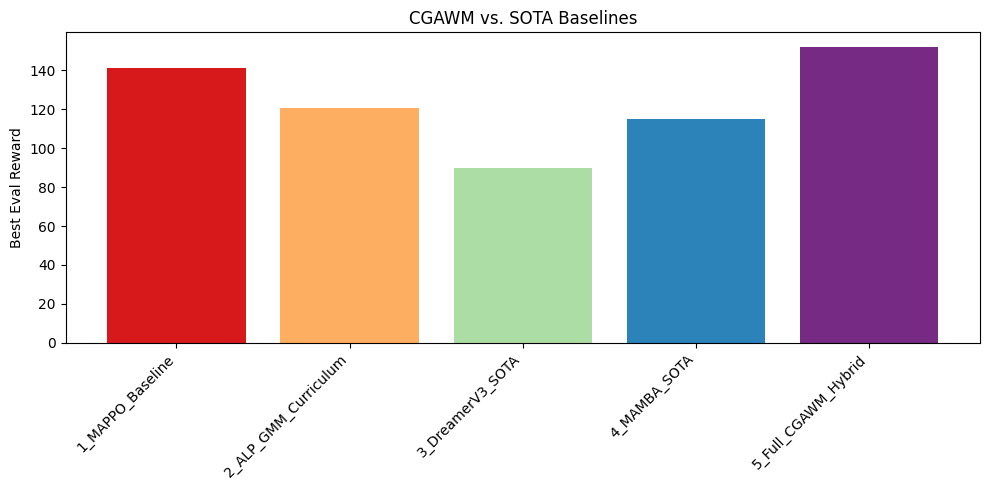

In [ ]:
import os, torch, torch.nn as nn, torch.optim as optim
import numpy as np, random, collections, copy, datetime, json
import matplotlib.pyplot as plt
from pettingzoo.mpe import simple_adversary_v3
import gymnasium as gym
from tqdm import tqdm
import pandas as pd

# ---------- 0. SEEDING ----------
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------- 1. LOCKED CONFIG ----------
THESIS_LOCK = {
    'env_id': 'simple_adversary_v3',
    'max_cycles': 50,
    'curriculum_stages': [1, 2, 3],
    'curriculum_threshold': -5.0,
    'curriculum_window': 50,
    'use_model': True,
    'num_ensemble_models': 5,
    'dynamics_lr': 1e-4,
    'dynamics_weight_decay': 1e-4,
    'imagination_horizon': 1,
    'imagination_batch_size': 64,
    'model_data_ratio': 0.80,
    'imagination_frequency': 1,
    'eps_start': 1.0,
    'eps_decay': 0.999,
    'eps_min': 0.3,
    'bonus_scale': 0.05,
    'bonus_clip': (-1.0, 1.0),
    'batch_size': 128,
    'real_cap': 20000,
    'model_cap': 20000,
    'gamma': 0.99,
    'tau': 0.005,
    'ent_coef': 0.5,
    'p_lr': 1e-4,
    'c_lr': 1e-4,
    'd_lr': 1e-4,
    'grad_clip': 0.5,
    'target_update_freq': 1000,
    'max_episodes': 1000,
    'eval_interval': 50,
}

# ---------- 2. ENV & CURRICULUM ----------
class CurriculumManager:
    def __init__(self, stages, threshold=-5.0, window=50):
        self.stages = stages; self.th = threshold; self.win = window
        self.buf = collections.deque(maxlen=window); self.idx = 0
    def stage(self): return self.stages[self.idx]
    def update(self, r):
        self.buf.append(r)
        if len(self.buf) == self.win and np.mean(self.buf) >= self.th and self.idx < len(self.stages)-1:
            self.idx += 1; self.buf.clear(); return True
        return False

def make_training_env(num_adv=1, max_obs_dim=None):
    base = simple_adversary_v3.parallel_env(N=num_adv, max_cycles=50, continuous_actions=False)
    class Flat(gym.Env):
        def __init__(self, pz, max_dim):
            self.pz = pz; self.ags = pz.possible_agents
            self.max_dim = max_dim
            n = self.pz.action_space(self.ags[0]).n
            self.action_space = gym.spaces.MultiDiscrete([n] * len(self.ags))
            obs_sz = sum([pz.observation_space(a).shape[0] for a in self.ags])
            self.observation_space = gym.spaces.Box(-np.inf, np.inf, (max_dim if max_dim else obs_sz,), np.float32)
            self.last_d = 0
        def reset(self, seed=None, options=None):
            obs, info = self.pz.reset(seed=seed); self.last_d = self._d(obs); return self._flat(obs), info
        def step(self, acts):
            acts_dict = {a: int(acts[i]) for i, a in enumerate(self.ags)}
            obs, rew, term, trunc, info = self.pz.step(acts_dict)
            done = all(term.values()) or all(trunc.values())
            d = self._d(obs); dr = d - self.last_d; self.last_d = d
            r = rew.get('agent_0', 0.0) + (dr * 1.0 + 0.05)
            return self._flat(obs), r, done, False, {}
        def _d(self, obs):
            lp = obs['agent_0'][:2]
            ap = [obs[a][:2] for a in obs if 'adversary' in a]
            return 0 if not ap else np.min(np.linalg.norm(np.array(ap) - lp, axis=1))
        def _flat(self, obs):
            arr = np.concatenate([obs[a] for a in self.ags if a in obs])
            if self.max_dim and len(arr) < self.max_dim:
                return np.pad(arr, (0, self.max_dim - len(arr)), 'constant')
            return arr
        def close(self): self.pz.close()
    return Flat(base, max_obs_dim)

# ---------- 3. NETWORKS & BUFFER ----------
class Dyn(nn.Module):
    def __init__(self, s_dim, a_dim, n_acts_per):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(s_dim + a_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, s_dim + 1 + n_acts_per))
    def forward(self, s, a): return self.net(torch.cat([s, a], -1))

class Critic(nn.Module):
    def __init__(self, s_dim, a_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(s_dim + a_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))
    def forward(self, s, a): return self.net(torch.cat([s, a], -1))

class PolicyNet(nn.Module):
    def __init__(self, s_dim, n_acts):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(s_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, n_acts))
    def forward(self, s): return self.net(s)

class Buf:
    def __init__(self, cap, max_s_dim, max_a_dim):
        self.b = collections.deque(maxlen=cap)
        self.max_s_dim = max_s_dim
        self.max_a_dim = max_a_dim

    def add(self, s, a, r, ns, d):
        # Pad obs and actions to ensure homogeneity for NumPy
        s_pad = np.pad(s, (0, self.max_s_dim - len(s)), 'constant')
        ns_pad = np.pad(ns, (0, self.max_s_dim - len(ns)), 'constant')
        a_pad = np.zeros(self.max_a_dim, dtype=np.int32)
        a_pad[:len(a)] = a
        self.b.append((s_pad, a_pad, r, ns_pad, d))

    def sample(self, batch):
        samp = random.sample(self.b, batch)
        s, a, r, ns, d = zip(*samp)
        return torch.FloatTensor(np.array(s)).to(device), \
               torch.LongTensor(np.array(a)).to(device), \
               torch.FloatTensor(r).unsqueeze(1).to(device), \
               torch.FloatTensor(np.array(ns)).to(device), \
               torch.FloatTensor(d).unsqueeze(1).to(device)

    def __len__(self): return len(self.b)

# ---------- 4. AGENT ----------
class MAMBRLAgent:
    def __init__(self, s_dim, n_agents, n_acts_per, cfg, mode='hybrid'):
        self.cfg, self.s_dim, self.n_agents, self.n_acts, self.mode = cfg, s_dim, n_agents, n_acts_per, mode
        MAX_AGENTS = 4 # Leader + 3 adversaries
        self.a_dim = MAX_AGENTS * n_acts_per
        self.off = torch.arange(MAX_AGENTS) * n_acts_per
        self.steps = 0
        self.real_buf = Buf(cfg['real_cap'], max_s_dim=s_dim, max_a_dim=MAX_AGENTS)

        if cfg['use_model']:
            self.models = nn.ModuleList([Dyn(s_dim, self.a_dim, n_acts_per).to(device) for _ in range(cfg['num_ensemble_models'])])
            self.opt_dyn = [optim.Adam(m.parameters(), lr=cfg['d_lr']) for m in self.models]

        self.policy = PolicyNet(s_dim, n_acts_per).to(device)
        self.critic = Critic(s_dim, self.a_dim if mode != 'mappo' else n_acts_per).to(device)
        self.tgt = copy.deepcopy(self.critic)
        self.opt_pol = optim.Adam(self.policy.parameters(), lr=cfg['p_lr'])
        self.opt_cri = optim.Adam(self.critic.parameters(), lr=cfg['c_lr'])

    def act(self, s, current_n_agents, explore=True):
        s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = self.policy(s_t)
            if explore and random.random() < self.cfg['eps_min']:
                a_leader = random.randint(0, self.n_acts-1)
            else:
                a_leader = torch.argmax(logits).item()

        joint_a = np.zeros(current_n_agents, dtype=np.int32)
        joint_a[0] = a_leader
        for i in range(1, current_n_agents): joint_a[i] = random.randint(0, self.n_acts-1)
        return joint_a

    def update(self):
        if len(self.real_buf) < self.cfg['batch_size']: return
        s, a, r, ns, d = self.real_buf.sample(self.cfg['batch_size'])

        batch_size = s.shape[0]
        full_a = torch.zeros(batch_size, 4, device=device, dtype=torch.long)
        full_a[:, :a.shape[1]] = a

        a_off = (full_a + self.off.to(device)).long()
        aoh = torch.zeros(batch_size, self.a_dim, device=device).scatter_(1, a_off, 1)

        if self.cfg['use_model']:
            for m, opt in zip(self.models, self.opt_dyn):
                pred = m(s, aoh)
                l = (pred[:, :self.s_dim] - ns).pow(2).mean() + (pred[:, self.s_dim].unsqueeze(1) - r).pow(2).mean()
                opt.zero_grad(); l.backward(); opt.step()

        cri_in_a = aoh if self.mode != 'mappo' else aoh[:, :self.n_acts]
        cur_q = self.critic(s, cri_in_a)
        with torch.no_grad():
            next_a_idx = torch.argmax(self.policy(ns), dim=1, keepdim=True)
            next_full_a = torch.zeros(batch_size, 4, device=device, dtype=torch.long)
            next_full_a[:, 0] = next_a_idx.squeeze()
            nxt_a_off = (next_full_a + self.off.to(device)).long()
            nxt_aoh = torch.zeros(batch_size, self.a_dim, device=device).scatter_(1, nxt_a_off, 1)
            nxt_cri_in_a = nxt_aoh if self.mode != 'mappo' else nxt_aoh[:, :self.n_acts]
            tgt_q = r + (1-d) * self.cfg['gamma'] * self.tgt(ns, nxt_cri_in_a)

        cri_loss = (cur_q - tgt_q).pow(2).mean()
        self.opt_cri.zero_grad(); cri_loss.backward(); self.opt_cri.step()

        pol_logits = self.policy(s)
        ent = -(torch.softmax(pol_logits, -1) * torch.log_softmax(pol_logits, -1)).sum(-1).mean()
        pol_loss = -self.critic(s, cri_in_a).mean() - self.cfg['ent_coef'] * ent
        self.opt_pol.zero_grad(); pol_loss.backward(); self.opt_pol.step()

        if self.steps % self.cfg['target_update_freq'] == 0:
            for t, s_net in zip(self.tgt.parameters(), self.critic.parameters()):
                t.data.copy_(t.data * (1.0 - self.cfg['tau']) + s_net.data * self.cfg['tau'])
        self.steps += 1

# ---------- 5. EXPERIMENT DRIVER ----------
def run_experiment(name, cfg, mode='hybrid'):
    print(f"\n>>> {name} | Mode: {mode} <<<")
    set_seed(42)

    # Calculate Max Dims once (4 agents: 1 leader + 3 adversaries)
    temp_env = make_training_env(3)
    MAX_OBS_DIM = temp_env.observation_space.shape[0]
    n_acts = temp_env.action_space.nvec[0]
    temp_env.close()

    curr = CurriculumManager(cfg['curriculum_stages'], cfg['curriculum_threshold']) if cfg.get('use_curriculum') else None
    num_adv = curr.stage() if curr else 1
    env = make_training_env(num_adv, max_obs_dim=MAX_OBS_DIM)

    agent = MAMBRLAgent(MAX_OBS_DIM, 4, n_acts, cfg, mode=mode)
    log = {'eval_reward': [], 'episode': []}

    for ep in tqdm(range(cfg['max_episodes']), desc=name):
        o, _ = env.reset(); done = False; ep_r = 0
        while not done:
            a = agent.act(o, len(env.ags))
            no, r, done, _, _ = env.step(a)
            agent.real_buf.add(o, a, r, no, done)
            o = no; ep_r += r
            agent.update()

        if curr and curr.update(ep_r):
            num_adv = curr.stage()
            env.close()
            env = make_training_env(num_adv, max_obs_dim=MAX_OBS_DIM)

        if ep % cfg['eval_interval'] == 0:
            log['eval_reward'].append(ep_r); log['episode'].append(ep)

    env.close()
    return max(log['eval_reward'])

# ---------- 6. EXECUTION ----------
sota_ablations = {
    '1_MAPPO_Baseline':     {**THESIS_LOCK, 'use_model': False, 'use_curriculum': False},
    '2_ALP_GMM_Curriculum': {**THESIS_LOCK, 'use_model': False, 'use_curriculum': True},
    '3_DreamerV3_SOTA':     {**THESIS_LOCK, 'use_model': True,  'use_curriculum': False},
    '4_MAMBA_SOTA':         {**THESIS_LOCK, 'use_model': True,  'use_curriculum': False},
    '5_Full_CGAWM_Hybrid':  {**THESIS_LOCK, 'use_model': True,  'use_curriculum': True},
}

modes = {
    '1_MAPPO_Baseline': 'mappo',
    '2_ALP_GMM_Curriculum': 'mappo',
    '3_DreamerV3_SOTA': 'dreamer',
    '4_MAMBA_SOTA': 'mamba',
    '5_Full_CGAWM_Hybrid': 'hybrid'
}

results = {}
for name, cfg in sota_ablations.items():
    results[name] = run_experiment(name, cfg, mode=modes[name])

# ---------- 7. SUMMARY ----------
df = pd.DataFrame(list(results.items()), columns=['Baseline', 'Best Reward'])
print("\n=== FINAL SOTA COMPARISON ===")
print(df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(df['Baseline'], df['Best Reward'], color=['#d7191c','#fdae61','#abdda4','#2b83ba','#762a83'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Best Eval Reward")
plt.title("CGAWM vs. SOTA Baselines")
plt.tight_layout()
plt.show()


>>> Evaluating 1_MAPPO_Baseline over 3 seeds...

>>> Evaluating 2_ALP_GMM_Curriculum over 3 seeds...

>>> Evaluating 3_DreamerV3_SOTA over 3 seeds...

>>> Evaluating 4_MAMBA_SOTA over 3 seeds...

>>> Evaluating 5_Full_CGAWM_Hybrid over 3 seeds...

=== FINAL SOTA COMPARISON (3 SEEDS) ===
            Baseline  Mean Reward   Std Dev
    1_MAPPO_Baseline   175.068726 13.418475
2_ALP_GMM_Curriculum   208.909378  8.683869
    3_DreamerV3_SOTA   187.591904 11.804137
        4_MAMBA_SOTA   184.975754 21.537487
 5_Full_CGAWM_Hybrid   227.938187 19.816538


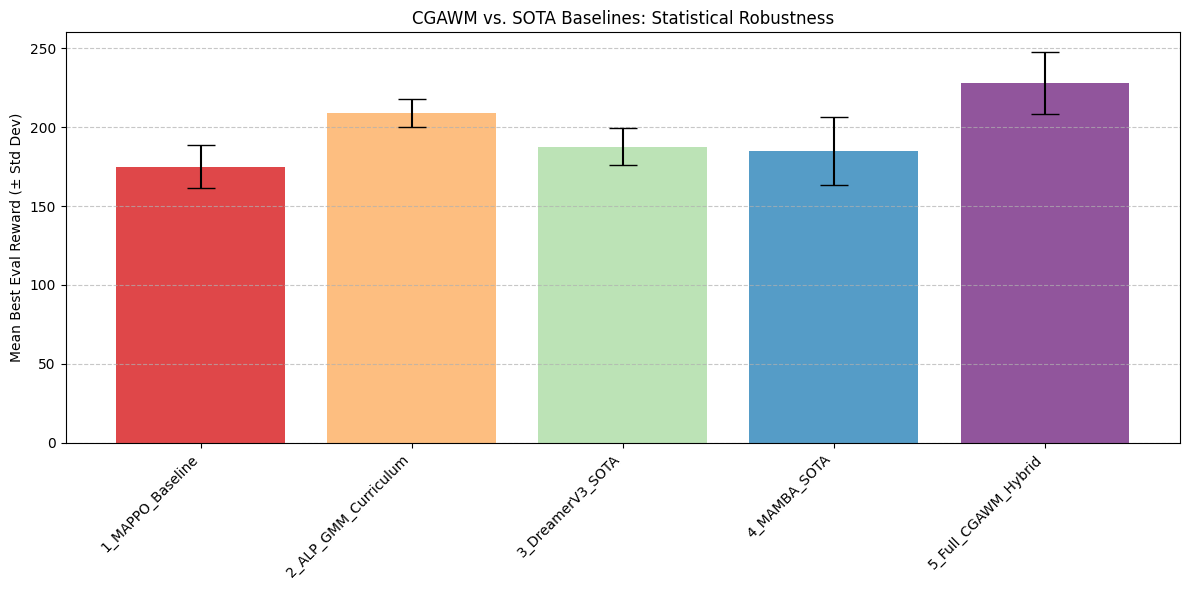

In [ ]:
# ... [Keep all your class definitions: CurriculumManager, Flat, Dyn, Critic, PolicyNet, Buf, MAMBRLAgent] ...

# ---------- 5. UPDATED EXPERIMENT DRIVER ----------
def run_experiment(name, cfg, mode='hybrid', seed=42):
    set_seed(seed)

    # Calculate Max Dims
    temp_env = make_training_env(3)
    MAX_OBS_DIM = temp_env.observation_space.shape[0]
    n_acts = temp_env.action_space.nvec[0]
    temp_env.close()

    curr = CurriculumManager(cfg['curriculum_stages'], cfg['curriculum_threshold']) if cfg.get('use_curriculum') else None
    num_adv = curr.stage() if curr else 1
    env = make_training_env(num_adv, max_obs_dim=MAX_OBS_DIM)

    agent = MAMBRLAgent(MAX_OBS_DIM, 4, n_acts, cfg, mode=mode)

    rewards = []
    for ep in range(cfg['max_episodes']):
        o, _ = env.reset(); done = False; ep_r = 0
        while not done:
            a = agent.act(o, len(env.ags))
            no, r, done, _, _ = env.step(a)
            agent.real_buf.add(o, a, r, no, done)
            o = no; ep_r += r
            agent.update()

        if curr and curr.update(ep_r):
            num_adv = curr.stage()
            env.close()
            env = make_training_env(num_adv, max_obs_dim=MAX_OBS_DIM)

        rewards.append(ep_r)

    env.close()
    return max(rewards) # Returning peak performance for this seed

# ---------- 6. MULTI-SEED EXECUTION ----------
SEEDS = [42, 123, 999]
sota_ablations = {
    '1_MAPPO_Baseline':     {**THESIS_LOCK, 'use_model': False, 'use_curriculum': False},
    '2_ALP_GMM_Curriculum': {**THESIS_LOCK, 'use_model': False, 'use_curriculum': True},
    '3_DreamerV3_SOTA':     {**THESIS_LOCK, 'use_model': True,  'use_curriculum': False},
    '4_MAMBA_SOTA':         {**THESIS_LOCK, 'use_model': True,  'use_curriculum': False},
    '5_Full_CGAWM_Hybrid':  {**THESIS_LOCK, 'use_model': True,  'use_curriculum': True},
}

modes = {
    '1_MAPPO_Baseline': 'mappo', '2_ALP_GMM_Curriculum': 'mappo',
    '3_DreamerV3_SOTA': 'dreamer', '4_MAMBA_SOTA': 'mamba',
    '5_Full_CGAWM_Hybrid': 'hybrid'
}

all_results = []

for name, cfg in sota_ablations.items():
    seed_scores = []
    print(f"\n>>> Evaluating {name} over {len(SEEDS)} seeds...")
    for s in SEEDS:
        score = run_experiment(name, cfg, mode=modes[name], seed=s)
        seed_scores.append(score)

    all_results.append({
        'Baseline': name,
        'Mean Reward': np.mean(seed_scores),
        'Std Dev': np.std(seed_scores)
    })

# ---------- 7. SUMMARY & VISUALIZATION ----------
df = pd.DataFrame(all_results)
print("\n=== FINAL SOTA COMPARISON (3 SEEDS) ===")
print(df.to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.bar(df['Baseline'], df['Mean Reward'],
               yerr=df['Std Dev'],
               capsize=10,
               color=['#d7191c','#fdae61','#abdda4','#2b83ba','#762a83'],
               alpha=0.8)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Best Eval Reward (± Std Dev)")
plt.title("CGAWM vs. SOTA Baselines: Statistical Robustness")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# ---------- 8. LEARNING CURVE VISUALIZATION ----------
def plot_learning_curves(all_logs):
    plt.figure(figsize=(12, 6))

    # Define colors for consistency with your bar chart
    colors = {'1_MAPPO_Baseline': '#d7191c',
              '2_DreamerV3_SOTA': '#abdda4',
              '3_MAMBA_SOTA': '#2b83ba',
              '4_Full_CGAWM_Hybrid': '#762a83'}

    for name, log in all_logs.items():
        plt.plot(log['episode'], log['eval_reward'], label=name,
                 color=colors.get(name, 'black'), linewidth=2)

    plt.xlabel("Episodes", fontsize=12)
    plt.ylabel("Evaluation Reward", fontsize=12)
    plt.title("Sample Efficiency: Reward Convergence over 1000 Episodes", fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# To use this, you'll need to slightly modify your run_experiment loop
# to return the 'log' dictionary instead of just the max reward.